# Procesamiento de Imágenes
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

El objetivo de este Notebook es explorar técnicas básicas de procesamiento de imágenes utilizando varias bibliotecas de Python, se utilizan 5 de ellas para mostrar diferentes funcionalidades y capacidades en el manejo de datos de imágenes.

Bibliotecas utilizadas:
- OpenCV
- NumPy
- MediaPipe
- Scikit-Image
- SciPy

Para esto, se utilizarán archivos de video en formato MP4 de una persona realizando un ejercio (backlever) en anillas de gimnasia.

Descargar e importar las bibliotecas necesarias

In [1]:
%pip install pymediainfo --quiet
%pip install opencv-python --quiet
%pip install moviepy===1.0.3 --quiet
%pip install librosa --quiet
%pip install mediapipe --quiet
%pip install scikit-image --quiet
%pip install numpy scipy matplotlib --quiet
%pip install matplotlib
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2                                         
import numpy as np    
import pandas as pd             
import matplotlib.pyplot as plt    
import mediapipe as mp           
from moviepy.editor import VideoFileClip 
from skimage import filters, exposure
from scipy.signal import savgol_filter 

Definir ruta de archivos.

In [3]:
DATA_PATH = './data'

## Inspección de de metadatos (OpenCV)
Primero, se inspeccionan los metadatos de los videos (cómo resolución, tamaño, fps, etc.) utilizando OpenCV.

In [4]:
file_metadata = {}
# Procesar todos los archivos de video en la carpeta
for file in os.listdir(DATA_PATH):
    if file.endswith('.mp4'):
        FILE_PATH = os.path.join(DATA_PATH, file)
        cap = cv2.VideoCapture(FILE_PATH)

        file_metadata[file] = {}
        # Resolución espacial
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        # Frames por segundo
        fps = cap.get(cv2.CAP_PROP_FPS)

        # Conteo total de frames y duración
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = frame_count / fps if fps > 0 else 0

        file_size = os.path.getsize(FILE_PATH) / (1024 * 1024)  # Tamaño en MB
            
        file_metadata[file]['width'] = width
        file_metadata[file]['height'] = height
        file_metadata[file]['size_MB'] = file_size
        file_metadata[file]['resolution'] = (width, height)
        file_metadata[file]['fps'] = fps
        file_metadata[file]['frame_count'] = frame_count
        file_metadata[file]['duration_seconds'] = duration

        cap.release()

In [5]:
# Mostrar los metadatos recopilados usando una tabla de pandas
metadata_df = pd.DataFrame.from_dict(file_metadata, orient='index')
display(metadata_df)

,width,height,size_MB,resolution,fps,frame_count,duration_seconds
125.mp4,3840,2160,142.860864,"(3840, 2160)",30.002941,612,20.398000
180.mp4,3840,2160,140.194414,"(3840, 2160)",30.002865,576,19.198167
225.mp4,3840,2160,115.195629,"(3840, 2160)",29.950363,570,19.031489
315.mp4,3840,2160,113.825327,"(3840, 2160)",30.003257,562,18.731300
90.mp4,3840,2160,113.212520,"(3840, 2160)",30.002936,562,18.731500


## Compresión de video (MoviePy)
Se comprimen los videos para reducir su tamaño utilizando MoviePy. Los videos fueron guardados con una resolución de 4K (3840x2160) y se reducen a una resolución de 1080p (1920x1080).


In [6]:
compressed_sufix = '_compressed.mp4'
target_res = 1080
compressed_videos = []
# Procesar todos los archivos de video en la carpeta
for file in os.listdir(DATA_PATH):
    print(f"Procesando archivo: {file}")
    if file.endswith('.mp4'):
        FILE_PATH = os.path.join(DATA_PATH, file)
        output_path = os.path.join(DATA_PATH, file.replace('.mp4', compressed_sufix))
        
        clip = VideoFileClip(FILE_PATH)

        # Reducción de resolución a 1080p
        clip_resized = clip.resize(height=target_res)

        # Guardar el video comprimido
        clip_resized.write_videofile(output_path, codec='libx264', audio_codec='aac')

        compressed_videos.append(output_path)

        # Resolución original y nueva
        original_res = (clip.w, clip.h)
        new_res = (clip_resized.w, clip_resized.h)
        print(f"Resolución original: {original_res}, Nueva resolución: {new_res}")

        clip.close()

Procesando archivo: 125.mp4
Moviepy - Building video ./data\125_compressed.mp4.
MoviePy - Writing audio in 125_compressedTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video ./data\125_compressed.mp4



Moviepy - Done !
Moviepy - video ready ./data\125_compressed.mp4
Resolución original: (3840, 2160), Nueva resolución: (1920, 1080)
Procesando archivo: 180.mp4
Moviepy - Building video ./data\180_compressed.mp4.
MoviePy - Writing audio in 180_compressedTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video ./data\180_compressed.mp4



Moviepy - Done !
Moviepy - video ready ./data\180_compressed.mp4
Resolución original: (3840, 2160), Nueva resolución: (1920, 1080)
Procesando archivo: 225.mp4
Moviepy - Building video ./data\225_compressed.mp4.
MoviePy - Writing audio in 225_compressedTEMP_MPY_wvf_snd.mp4


...

Moviepy - Done !
Moviepy - video ready ./data\225_compressed.mp4
Resolución original: (3840, 2160), Nueva resolución: (1920, 1080)
Procesando archivo: 315.mp4
Moviepy - Building video ./data\315_compressed.mp4.
MoviePy - Writing audio in 315_compressedTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video ./data\315_compressed.mp4



Moviepy - Done !
Moviepy - video ready ./data\315_compressed.mp4
Resolución original: (3840, 2160), Nueva resolución: (1920, 1080)
Procesando archivo: 90.mp4
Moviepy - Building video ./data\90_compressed.mp4.
MoviePy - Writing audio in 90_compressedTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video ./data\90_compressed.mp4



Moviepy - Done !
Moviepy - video ready ./data\90_compressed.mp4
Resolución original: (3840, 2160), Nueva resolución: (1920, 1080)


Comparamos el fotograma 100 del video original y el comprimido para observar la diferencia en calidad.

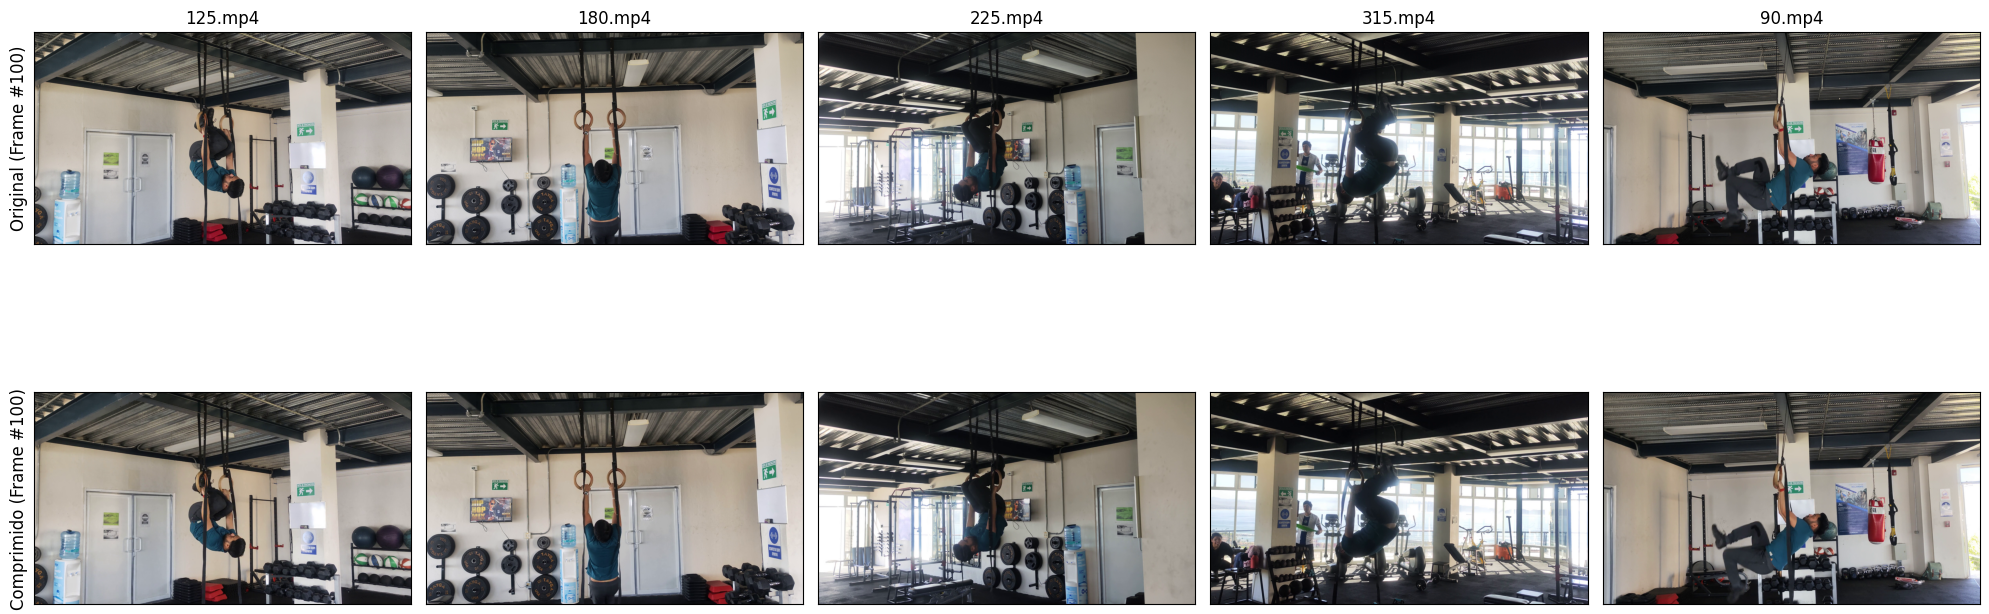

In [7]:
# Comparacion de fotogramas entre videos originales y comprimidos

fig, axes = plt.subplots(2, 5, figsize=(20, 9))

video_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.mp4') and not f.endswith(compressed_sufix)]
video_files.sort()

for col, file in enumerate(video_files):
    original_path = os.path.join(DATA_PATH, file)
    compressed_path = os.path.join(DATA_PATH, file.replace('.mp4', compressed_sufix))
    
    cap_orig = cv2.VideoCapture(original_path)
    cap_comp = cv2.VideoCapture(compressed_path)
    
    # Seleccionar el fotograma 100
    cap_orig.set(cv2.CAP_PROP_POS_FRAMES, 100)
    cap_comp.set(cv2.CAP_PROP_POS_FRAMES, 100)
    
    ret_orig, frame_orig = cap_orig.read()
    ret_comp, frame_comp = cap_comp.read()
    

    axes[0, col].imshow(cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(file)
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
        
    axes[1, col].imshow(cv2.cvtColor(frame_comp, cv2.COLOR_BGR2RGB))
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])
    
    cap_orig.release()
    cap_comp.release()

axes[0, 0].set_ylabel('Original (Frame #100)', fontsize=12)
axes[1, 0].set_ylabel('Comprimido (Frame #100)', fontsize=12)

plt.tight_layout()
plt.show()

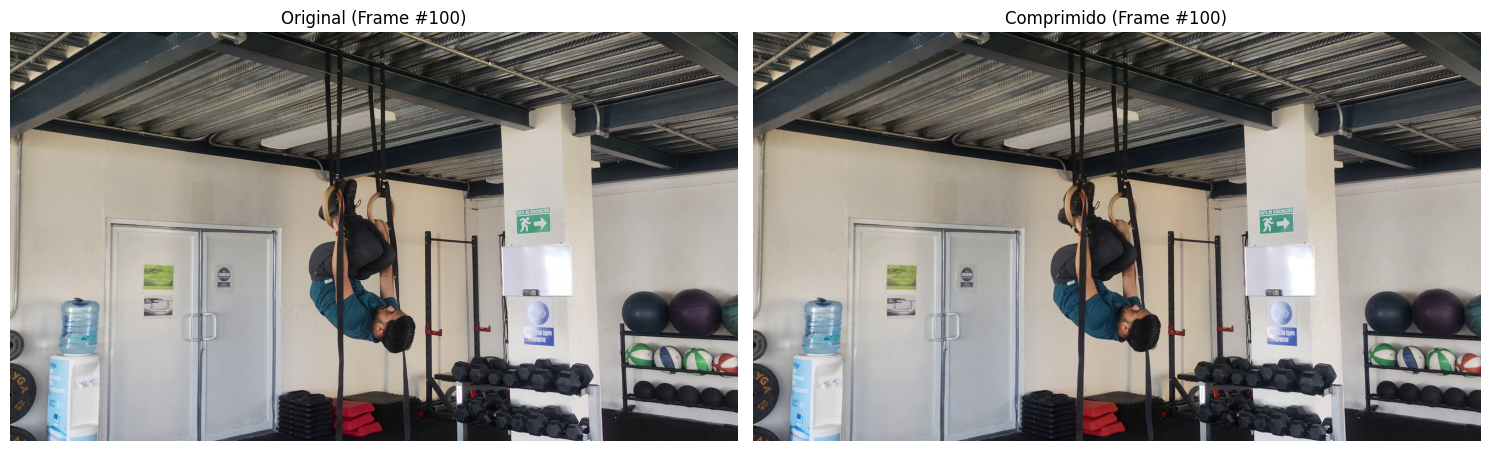

In [8]:
# Comparacion individual

file = video_files[0]  # Seleccionamos un video
original_path = os.path.join(DATA_PATH, file)
compressed_path = os.path.join(DATA_PATH, file.replace('.mp4', compressed_sufix))

cap_orig = cv2.VideoCapture(original_path)
cap_comp = cv2.VideoCapture(compressed_path)
cap_orig.set(cv2.CAP_PROP_POS_FRAMES, 100)
cap_comp.set(cv2.CAP_PROP_POS_FRAMES, 100)

ret_orig, frame_orig = cap_orig.read()
ret_comp, frame_comp = cap_comp.read()


plt.figure(figsize=(15, 12))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB))
plt.title('Original (Frame #100)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(frame_comp, cv2.COLOR_BGR2RGB))
plt.title('Comprimido (Frame #100)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Operaciones con Numpy y OpenCV
Utilizamos Numpy y OpenCV para manipular la matriz de píxeles de un fotograma específico del video.

Convertimos la imagen a escala de grises, posteriormente se define una máscara ROI a la cual se le aumenta el brillo sumando una constante a los valores de intensidad de píxeles.

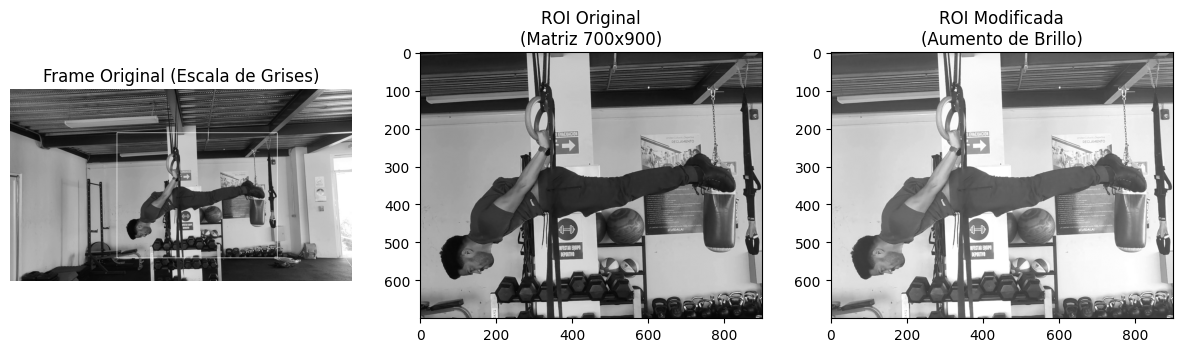

In [9]:
file = video_files[4]  # Seleccionamos un video
original_path = os.path.join(DATA_PATH, file)
compressed_path = os.path.join(DATA_PATH, file.replace(".mp4", compressed_sufix))

cap = cv2.VideoCapture(compressed_path)

# Ir al milisegundo 12500 (12.5s)
cap.set(cv2.CAP_PROP_POS_MSEC, 12500)
ret, frame = cap.read()
cap.release()


# Convertir a Escala de Grises
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# --- Definir la máscara ROI ---
# Coordenadas del recuadro
y_start, x_start = 250, 600
y_end = y_start + 700
x_end = x_start + 900
# Tamaño de la máscara
roi = gray_frame[y_start : y_end, x_start : x_end]

# Sumar una constante a la matriz para aumentar el brillo
brillo_extra = 50
roi_modificada = cv2.add(
    roi, brillo_extra
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Frame completo con el cuadro marcado
frame_con_recuadro = gray_frame.copy()
cv2.rectangle(
    frame_con_recuadro,
    (x_start, y_start),
    (x_end, y_end),
    (255, 255, 255),
    2,
)

axes[0].imshow(frame_con_recuadro, cmap="gray")
axes[0].set_title("Frame Original (Escala de Grises)")
axes[0].axis("off")

# Zoom a la matriz original (Visualización como imagen "pixelada")
axes[1].imshow(roi, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"ROI Original\n(Matriz {roi.shape[0]}x{roi.shape[1]})")

# Zoom a la matriz modificada
axes[2].imshow(roi_modificada, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("ROI Modificada\n(Aumento de Brillo)")

plt.show()

Aplicación de una pequeña rotación para enderezar la imagen y recorte.

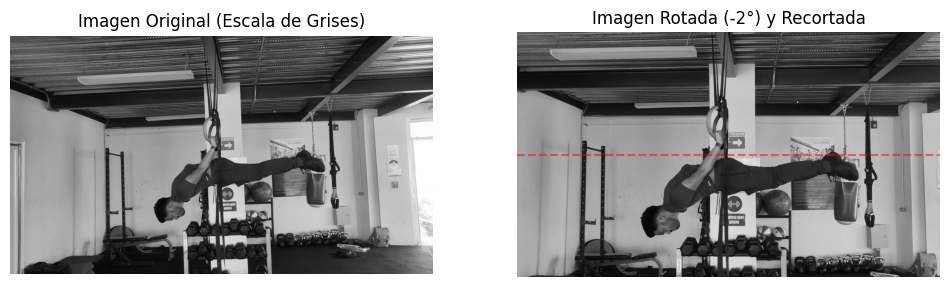

In [10]:
(h, w) = gray_frame.shape[:2]
center = (w // 2, h // 2)

# Definir el Ángulo de Corrección
angulo_correccion = -2

# Obtener la Matriz de Rotación
M = cv2.getRotationMatrix2D(center, angulo_correccion, 1.0)

# Aplicar la transformación
frame_rotado = cv2.warpAffine(gray_frame, M, (w, h))

# Recorte
recorte_y_start, recorte_y_end = 100, h - 100
recorte_x_start, recorte_x_end = 200, w - 200

frame_final = frame_rotado[recorte_y_start:recorte_y_end, 
                           recorte_x_start:recorte_x_end]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gray_frame, cmap='gray')
axes[0].set_title('Imagen Original (Escala de Grises)')
axes[0].axis('off')

# Dibujar linea de referencia horizontal en el centro
axes[1].imshow(frame_final, cmap='gray')
axes[1].axhline(y=frame_final.shape[0]//2, color='r', linestyle='--', alpha=0.5)
axes[1].set_title(f'Imagen Rotada ({angulo_correccion}°) y Recortada')
axes[1].axis('off')

plt.show()

## Extracción de características (Puntos de referencia) mediante MediaPipe
Utilizamos MediaPipe para detectar y extraer puntos de referencia del cuerpo humano en los videos comprimidos.

In [11]:
from tqdm import tqdm
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

Esta biblioteca requiere descargar el modelo, en este caso utilizamos el modelo de pose humana (tamaño medio) para detectar los puntos de referencia del cuerpo.

In [12]:
# !wget -O pose_landmarker_full.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task
model_path = 'pose_landmarker_full.task'

Definimos las opciones del modelo

In [13]:
BaseOptions = mp.tasks.BaseOptions

PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=True
)

Las funciones debajo se utilizan para dibujar los puntos de referencia y las conexiones entre ellos en la imagen. MediaPipe dejó de proporcionar estas funcionalidades, las cuales estaban antes en el modulo de 'solutions'.

In [16]:
POSE_CONNECTIONS = [
    # Cara
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 7),
    (0, 4),
    (4, 5),
    (5, 6),
    (6, 8),
    (9, 10),
    # Torso
    (11, 12),
    (11, 23),
    (12, 24),
    (23, 24),
    # Brazo izquierdo
    (11, 13),
    (13, 15),
    (15, 17),
    (15, 19),
    (15, 21),
    (17, 19),
    # Brazo derecho
    (12, 14),
    (14, 16),
    (16, 18),
    (16, 20),
    (16, 22),
    (18, 20),
    # Pierna izquierda
    (23, 25),
    (25, 27),
    (27, 29),
    (27, 31),
    (29, 31),
    # Pierna derecha
    (24, 26),
    (26, 28),
    (28, 30),
    (28, 32),
    (30, 32),
]


def to_pixel(x_norm: float, y_norm: float, w: int, h: int) -> tuple[int, int]:
    """Convierte coordenadas normalizadas [0,1] a píxeles."""
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)


def draw_landmarks_on_image(
    rgb_image: np.ndarray,
    detection_result,
    landmark_color=(255, 0, 0), 
    connection_color=(0, 255, 0), 
    landmark_radius=5,
    connection_thickness=2,
    visibility_threshold=0.5,
) -> np.ndarray:

    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    h, w = annotated_image.shape[:2]

    # Iterar sobre cada pose detectada
    for pose_landmarks in pose_landmarks_list:
        # Convertir landmarks a coordenadas de píxeles
        pixel_coords = []
        for landmark in pose_landmarks:
            px, py = to_pixel(landmark.x, landmark.y, w, h)
            visibility = landmark.visibility if hasattr(landmark, "visibility") else 1.0
            pixel_coords.append((px, py, visibility))

        # Dibujar las conexiones (líneas entre landmarks)
        for start_idx, end_idx in POSE_CONNECTIONS:
            if start_idx < len(pixel_coords) and end_idx < len(pixel_coords):
                start_point = pixel_coords[start_idx]
                end_point = pixel_coords[end_idx]

                # Dibujar estan separados
                if (
                    start_point[2] > visibility_threshold
                    and end_point[2] > visibility_threshold
                ):
                    cv2.line(
                        annotated_image,
                        (start_point[0], start_point[1]),
                        (end_point[0], end_point[1]),
                        connection_color,
                        connection_thickness,
                    )

        # Dibujar los landmarks (círculos)
        for idx, (px, py, visibility) in enumerate(pixel_coords):
            if visibility > visibility_threshold:
                cv2.circle(
                    annotated_image, (px, py), landmark_radius, landmark_color, -1
                )
                cv2.circle(annotated_image, (px, py), landmark_radius, (0, 0, 0), 1)

    return annotated_image

In [ ]:
for video in tqdm(compressed_videos):
    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        cap = cv2.VideoCapture(video)

        # Obtenemos propiedades del video
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        output_video = video.replace(compressed_sufix, "_processed.mp4")

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

        frame_idx = 0
        all_landmarks = []  # Almacenar landmarks de todos los frames

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Convertir BGR a RGB para MediaPipe
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Crear imagen de MediaPipe
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

            # Calcular timestamp en milisegundos
            timestamp_ms = int((frame_idx / fps) * 1000)

            # Detectar poses
            detection_result = landmarker.detect_for_video(mp_image, timestamp_ms)

            # Dibujar landmarks en el frame
            annotated_frame = draw_landmarks_on_image(frame_rgb, detection_result)

            # Almacenar landmarks si se detectaron
            if detection_result.pose_landmarks:
                frame_landmarks = {
                    'frame': frame_idx,
                    'timestamp_ms': timestamp_ms,
                    'landmarks': [
                        {'x': lm.x, 'y': lm.y, 'z': lm.z, 'visibility': lm.visibility}
                        for lm in detection_result.pose_landmarks[0]
                    ]
                }
                all_landmarks.append(frame_landmarks)

            # Convertir de vuelta a BGR para OpenCV
            annotated_frame_bgr = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)

            # Escribir frame al video de salida
            out.write(annotated_frame_bgr)

            frame_idx += 1

        cap.release()
        out.release()

 60%|██████    | 3/5 [01:32<01:01, 30.63s/it]

Comparamos un fotograma del video original con el video procesado con los puntos de referencia detectados.

In [ ]:
processed_videos = [v.replace(compressed_sufix, "_processed.mp4") for v in compressed_videos]

fig, axes = plt.subplots(2, len(compressed_videos), figsize=(20, 9))

for col, (comp_video, proc_video) in enumerate(zip(compressed_videos, processed_videos)):
    cap_comp = cv2.VideoCapture(comp_video)
    cap_proc = cv2.VideoCapture(proc_video)
    
    target_frame = 30*12.5
    cap_comp.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    cap_proc.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    
    ret_comp, frame_comp = cap_comp.read()
    ret_proc, frame_proc = cap_proc.read()
    
    if ret_comp and ret_proc:
        axes[0, col].imshow(cv2.cvtColor(frame_comp, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(os.path.basename(comp_video), fontsize=10)
        axes[0, col].set_xticks([])
        axes[0, col].set_yticks([])
        
        axes[1, col].imshow(cv2.cvtColor(frame_proc, cv2.COLOR_BGR2RGB))
        axes[1, col].set_xticks([])
        axes[1, col].set_yticks([])
    
    cap_comp.release()
    cap_proc.release()

axes[0, 0].set_ylabel('Video Comprimido', fontsize=12)
axes[1, 0].set_ylabel('Con Pose Landmarks', fontsize=12)

plt.suptitle(f'Comparación de Frames (Frame #{target_frame})', fontsize=14)
plt.tight_layout()
plt.show()